In [20]:
import sys
sys.path.append("/project01/ndcms/atownse2/ExponentialMixtureModel")

import ROOT
import numpy as np
import matplotlib.pyplot as plt

from tools import scale_out as so
import emm

In [2]:
# Load the data
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)

data_tree = emm.get_data(tree=True)
data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))

Loaded 5036 diphoton invariant masses from data.


In [35]:
# Get the binning for the visualization
bins = emm.get_fine_binning()

In [12]:
fit_options = [
    # ROOT.RooFit.IntegrateBins(0.0001),
    ROOT.RooFit.PrintLevel(-1),
    # ROOT.RooFit.Offset(True),
    # ROOT.RooFit.Strategy(2),
    ROOT.RooFit.Save(),
    # ROOT.RooFit.Range("fit_range")
]

In [19]:
# Do model selection
model_primitives = [
    emm.ExponentialMixtureModel_1,
    emm.ExponentialMixtureModel_2,
    emm.ExponentialMixtureModel_3,
    emm.ExponentialMixtureModel_4,
]

results = {}

for mp in model_primitives:
    print(f"Fitting {mp.name}...")
    fit_result = emm.fit_random_restarts(
        x, data, mp,
        seed=42,
        n_samples=20, n_retries=5,
        save=False, fit_options=fit_options
    )
    print(f"   Number of minima found: {len(fit_result)}")
    print(f"   NLLs: {[res['nll'] for res in fit_result]}")

    best_fit = fit_result[-1]
    model = mp(x)
    model.set_params(best_fit["final_pars"])

    aic = 2*len(model.params()) + 2*best_fit["nll"]
    bic = len(model.params())*np.log(data.numEntries()) + 2*best_fit["nll"]
    print(f"   Best fit: nll = {best_fit['nll']:.1f}")
    print(f"   AIC: {aic:.1f}, BIC: {bic:.1f}")
    results[mp.name] = {
        "AIC": aic,
        "BIC": bic,
    }


Fitting ExponentialMixture-1...
   Number of minima found: 2
   NLLs: [31096.402546551373, 31096.402546497528]
   Best fit: nll = 31096.4
   AIC: 62196.8, BIC: 62209.9
Fitting ExponentialMixture-2...
   Number of minima found: 3
   NLLs: [31030.606013386074, 31030.60600988946, 31030.6060098254]
   Best fit: nll = 31030.6
   AIC: 62069.2, BIC: 62095.3
Fitting ExponentialMixture-3...
   Number of minima found: 2
   NLLs: [31030.6060522073, 31030.59436498653]
   Best fit: nll = 31030.6
   AIC: 62073.2, BIC: 62112.3
Fitting ExponentialMixture-4...
   Number of minima found: 5
   NLLs: [31030.60402544388, 31030.60192912878, 31030.601210608635, 31030.592374465403, 31030.405319277255]
   Best fit: nll = 31030.4
   AIC: 62076.8, BIC: 62129.0
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (pdf_0)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeC

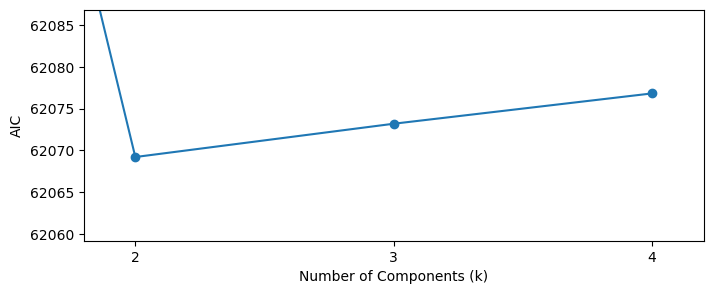

In [33]:
# Plot the AIC
fig, ax = plt.subplots(figsize=(8, 3))
model_names = list(results.keys())
ks = [int(model_name.split("-")[-1]) for model_name in model_names]
aic_values = [results[name]["AIC"] for name in model_names]
ax.plot(ks, aic_values, marker="o")
ax.set_xticks(ks)
ax.set_ylabel("AIC")
ax.set_xlabel("Number of Components (k)")
ax.set_xlim(1.8, 4.2)
ax.set_ylim(min(aic_values[1:]) - 10, max(aic_values[1:]) + 10)
plt.show()

Fitting model: f_1
   Fit time: 0.9 seconds
   Number of minima found: 3
   NLLs: [31033.020597768118, 31033.020439470667, 31033.02043321267]
   AIC: 62070.0, BIC: 62083.1
Fitting model: f_2
   Fit time: 1.2 seconds
   Number of minima found: 3
   NLLs: [31032.230570705913, 31032.230473861116, 31032.230472985048]
   AIC: 62068.5, BIC: 62081.5
Fitting model: f_3
   Fit time: 1.4 seconds
   Number of minima found: 4
   NLLs: [31033.492869298516, 31033.492694015968, 31033.492648938533, 31033.492645056547]
   AIC: 62071.0, BIC: 62084.0
Fitting model: f_4
   Fit time: 6.1 seconds
   Number of minima found: 3
   NLLs: [31032.16984603116, 31032.168916278246, 31032.16661315141]
   AIC: 62070.3, BIC: 62089.9
Fitting model: ExponentialMixture-2
   Fit time: 1.3 seconds
   Number of minima found: 4
   NLLs: [31030.826429147255, 31030.826426152904, 31030.826425677045, 31030.82642474516]
   AIC: 62069.7, BIC: 62095.8
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric in

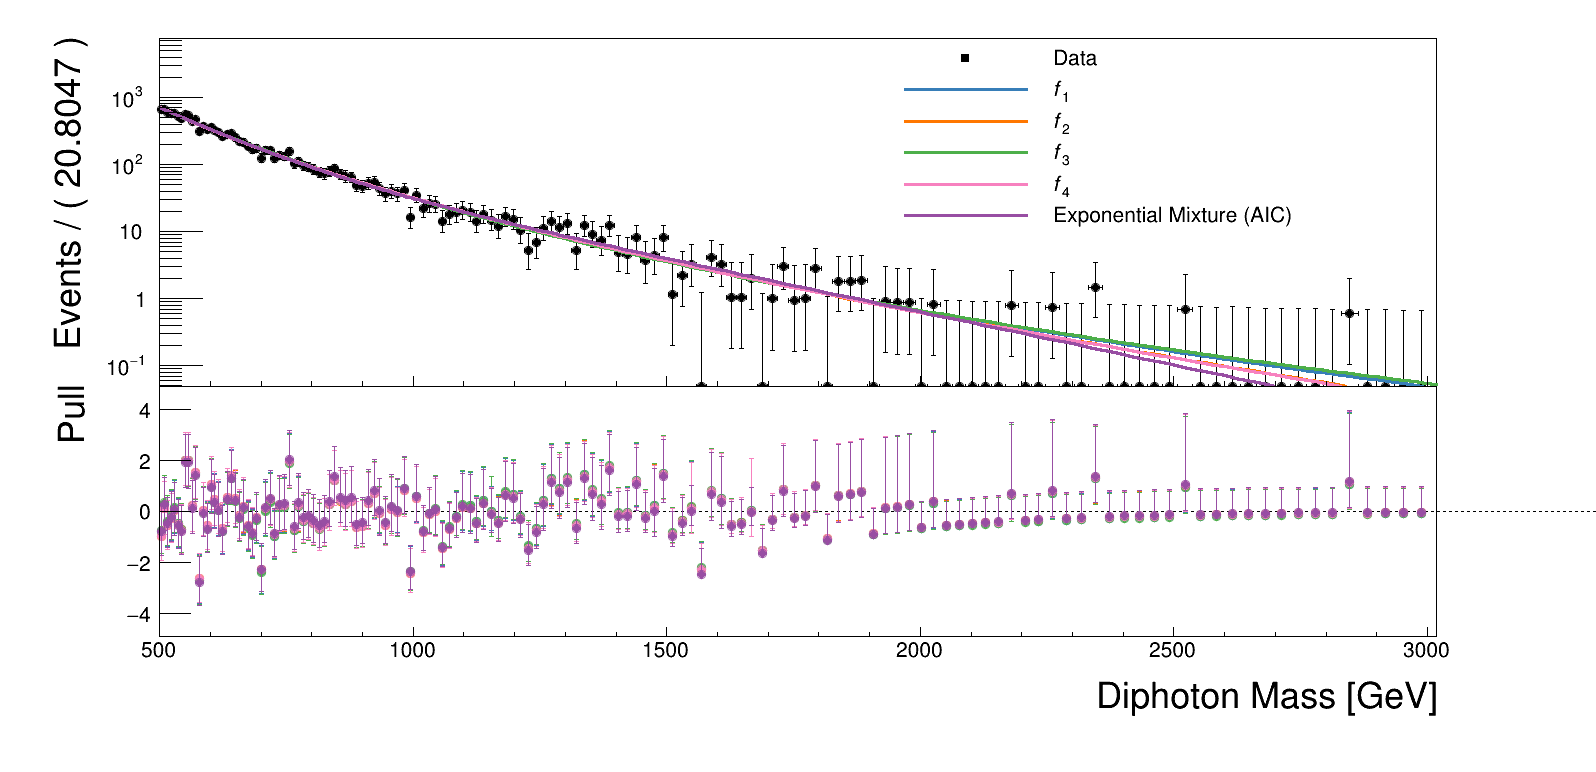

In [40]:
# Fit and plot
model_primitives = [
    emm.f1,
    emm.f2,
    emm.f3,
    emm.f4,
    emm.ExponentialMixtureModel_2,
]

models = []
model_labels = []
for model_primitive in model_primitives:
    print(f"Fitting model: {model_primitive.name}")
    t0 = ROOT.TStopwatch()
    fit_result = emm.fit_random_restarts(
        x, data, model_primitive,
        seed=42, n_samples=20, n_retries=5,
        save=False,
        fit_options=fit_options
        )
    t1 = t0.RealTime()
    print(f"   Fit time: {t1:.1f} seconds")
    print(f"   Number of minima found: {len(fit_result)}")
    print(f"   NLLs: {[res['nll'] for res in fit_result]}")
    best_fit = fit_result[-1]
    model = model_primitive(x)
    model.set_params(best_fit["final_pars"])
    if "ExponentialMixture" in model.name:
        k = model.name.split("-")[-1]
        model_label = f"Exponential Mixture (AIC)"
    else:
        model_func = "_".split(model.name)[0]
        model_num = model.name.split("_")[-1]
        model_label = f"#it{{f}}_{{{model_num}}}"

    nll = best_fit["nll"]
    n = data.numEntries()
    k = len(model.params())
    aic = 2*k + 2*nll
    bic = k*np.log(n) + 2*nll
    print(f"   AIC: {aic:.1f}, BIC: {bic:.1f}")

    # model_label += f" $(\\chi^2 = {_1:.1f})$"
    
    models.append(model)
    model_labels.append(model_label)

from array import array
bin_array = array('d', bins)
binning = ROOT.RooBinning(len(bins)-1, bin_array)
x.setBinning(binning)
emm.plot_fits(
    data, x, models,
    model_labels=model_labels,
    # title="CMS High Mass Diphoton Spectrum",
    plot_range=(500, 3000),
    # nbins=128,
    y_min=5e-2,
    )


In [31]:
models[-2].print()
models[-1].print()

Model: ExponentialMixture-2
raw_rate_0: 0.7267653717150296 + -1.0 1.0
raw_rate_1: 1.737329945481105 + -1.0 1.0
raw_weight_0: 0.0 + -1.0 1.0
raw_weight_1: 0.467984211986748 + -1.0 1.0
Model: ExponentialMixture-3
raw_rate_0: 1.736943552541625 + -1.0 1.0
raw_rate_1: 0.7268630382560864 + -1.0 1.0
raw_rate_2: 1.7384035697124864 + -1.0 1.0
raw_weight_0: 0.0 + -1.0 1.0
raw_weight_1: 0.49237525998776543 + -1.0 1.0
raw_weight_2: -13.462209868235535 + -1.0 1.0
